#Kavish Nag
#24070126085
#AIML B1

In [1]:
import torch

In [2]:
#scaler
a = torch.tensor(5.0) #Tensor in simple words is an array.
#store informtion
print("Array")
print(a)

#vector
b = torch.tensor([1,2,3])
print("Vector")
print(b)

#matrix
c = torch.tensor([[1,2,3],[4,5,6]])
print('Matrix')
print(c)

Array
tensor(5.)
Vector
tensor([1, 2, 3])
Matrix
tensor([[1, 2, 3],
        [4, 5, 6]])


- For ml -> machine learning
- For dl -> tensorflow , keras , pytorch

In [3]:
#Generating randoms
d1 = torch.rand(2,3)
d2 = torch.rand(2,3)
print(d1)
print(d2)

tensor([[0.3357, 0.5808, 0.2659],
        [0.2913, 0.4106, 0.3439]])
tensor([[0.2341, 0.8042, 0.9990],
        [0.7540, 0.1354, 0.8900]])


In [4]:
#Operations
s = d1+d2
print("Sum: ",s)

Sum:  tensor([[0.5698, 1.3850, 1.2649],
        [1.0453, 0.5461, 1.2339]])


A perceptron is the simplest form of an artificial neural network, functioning as a single-layer algorithm for the supervised learning of binary classifiers.



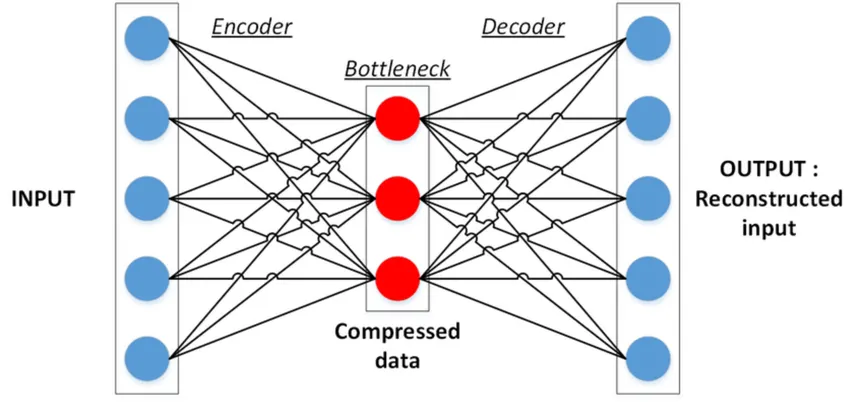

In [5]:
import torch.nn as nn
import torch

layer = nn.Linear(4,2) # 4 input features and 2 features as output
x = torch.tensor([1.0,2.0,3.0,4.0])
output = layer(x)
print(output)

tensor([-0.9258, -2.1713], grad_fn=<ViewBackward0>)


In [6]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4,3)
        self.fc2 = nn.Linear(3,2)

    def forward(self,x):
        x = self.fc1(x)
        x = self.fc2(x)
        return x

net = SimpleNet()
x=torch.tensor([1.0,2.0,3.0,4.0])
output = net(x)
print(output)

tensor([ 0.2294, -0.1198], grad_fn=<ViewBackward0>)


#Activation function


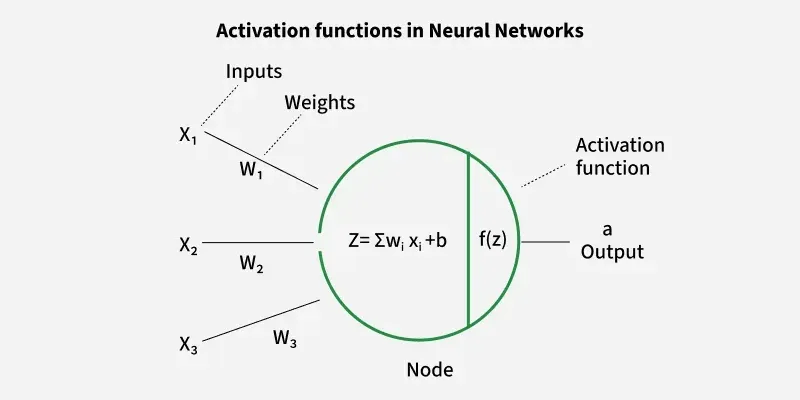

Currently using ReLu funtion
- f(z) is relu function
- if Z = 0, it is passed to f(z)

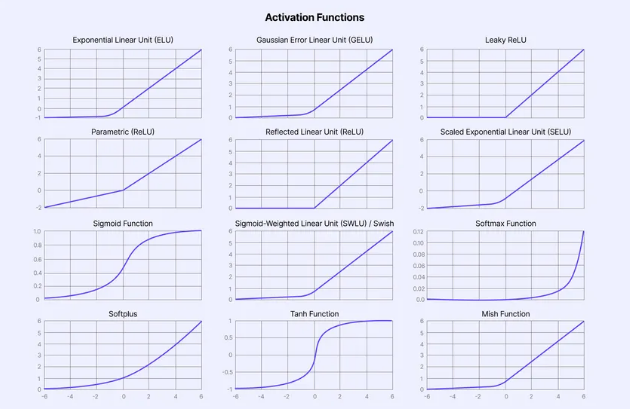

In [7]:
x = torch.tensor([-2.0,-1.0,0.0,1.0,2.0])
relu = nn.ReLU() #gives value as 0 for all negative values and start increasing for positive values
sigmoid = nn.Sigmoid() #Useful for normalization

print(relu(x))
print(sigmoid(x))


tensor([0., 0., 0., 1., 2.])
tensor([0.1192, 0.2689, 0.5000, 0.7311, 0.8808])


##Loss Function

In [8]:
loss_fn = nn.MSELoss()

pred = torch.tensor([0.2,0.8]) #if we increase 0.8 to 0.9, the loss will decrease, and if we decrease 0.8 then loss will increase
# in short, no loss when pred = target, otherwise lower loss when values closer to target, otherwise more with more distance
target = torch.tensor([0.0,1.0])

loss = loss_fn(pred,target)
loss

tensor(0.0400)

#Optimizers

In [9]:
import torch.optim as optim

model = nn.Linear(4,2)
optimizer = optim.Adam(model.parameters(),lr=0.01) #lr indicates learning rate
#Adam -> Adaptive moment Estimator
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


#AUTOENCODER
1. Encoder
- Compress the input
- Turns the original data into a smaller representation
2. Latent space
- The compressed representation
- Sometimes called the code or embedding
3. Decoder
- Tries to rebuild the original input

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

In [13]:
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader= DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 63.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.73MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.36MB/s]


In [14]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

device

device(type='cpu')

In [16]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        # flatten images from [batch, 1, 28, 28] to [batch, 784]
        images = images.view(images.size(0), -1).to(device)

        # forward pass
        outputs = model(images)

        # reconstruction loss
        loss = criterion(outputs, images)

        # clear old gradients
        optimizer.zero_grad()

        # backpropagation
        loss.backward()

        # update weights
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.6f}")

Epoch [1/10] - Loss: 0.047702
Epoch [2/10] - Loss: 0.025043
Epoch [3/10] - Loss: 0.020263
Epoch [4/10] - Loss: 0.017101
Epoch [5/10] - Loss: 0.015187
Epoch [6/10] - Loss: 0.013943
Epoch [7/10] - Loss: 0.013033
Epoch [8/10] - Loss: 0.012301
Epoch [9/10] - Loss: 0.011650
Epoch [10/10] - Loss: 0.011111


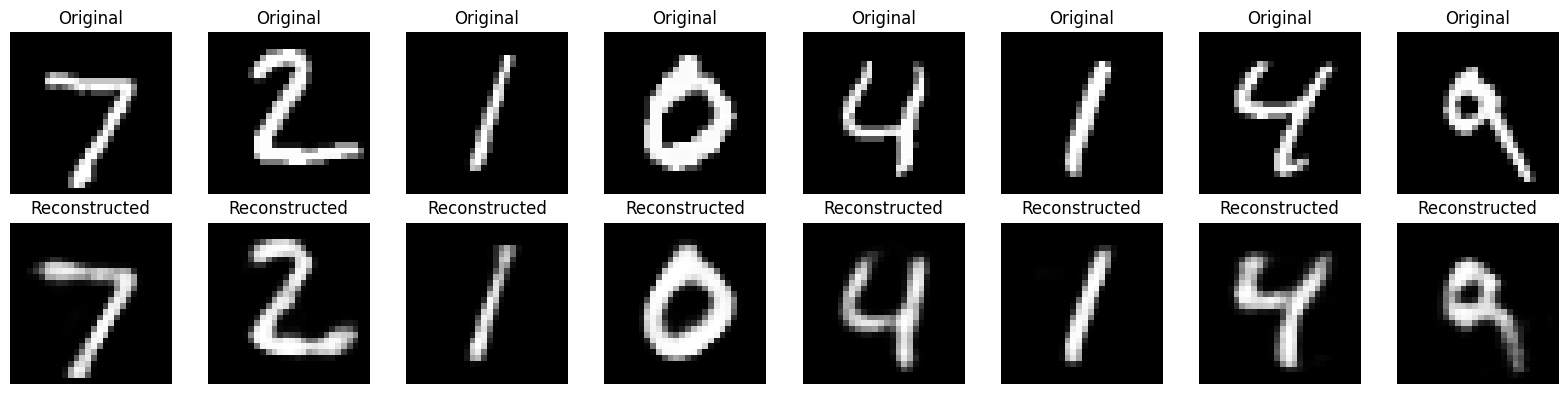

In [18]:
import matplotlib.pyplot as plt
model.eval()

with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.view(images.size(0), -1).to(device)

    reconstructed = model(images)

images = images.cpu().view(-1, 1, 28, 28)
reconstructed = reconstructed.cpu().view(-1, 1, 28, 28)

n = 8
plt.figure(figsize=(16, 4))

for i in range(n):
    # original
    plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # reconstructed
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

Epoch [1/10] - Loss: 0.058937
Epoch [2/10] - Loss: 0.029517
Epoch [3/10] - Loss: 0.023755
Epoch [4/10] - Loss: 0.020686
Epoch [5/10] - Loss: 0.018283
Epoch [6/10] - Loss: 0.016738
Epoch [7/10] - Loss: 0.015620
Epoch [8/10] - Loss: 0.014661
Epoch [9/10] - Loss: 0.013839
Epoch [10/10] - Loss: 0.013201


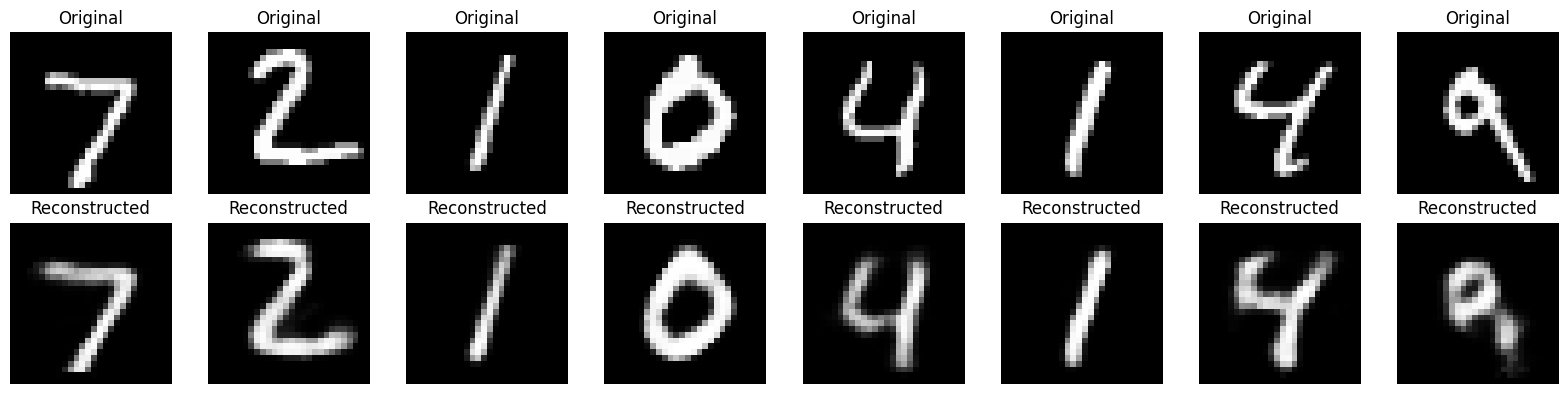

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# data
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed

model = Autoencoder().to(device)

# loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# training
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.view(images.size(0), -1).to(device)

        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.6f}")

# visualize
model.eval()

with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.view(images.size(0), -1).to(device)
    reconstructed = model(images)

images = images.cpu().view(-1, 1, 28, 28)
reconstructed = reconstructed.cpu().view(-1, 1, 28, 28)

n = 8
plt.figure(figsize=(16, 4))

for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()